# LIBERO Input Layout Debug

This notebook visualizes what DreamZero sees for LIBERO after the new left-right two-view layout and the shared vertical flip correction.

It checks four things on the same demo frames:

1. Raw LIBERO `agentview_rgb` and `eye_in_hand_rgb`
2. Train-time model input after `DreamTransform._prepare_video()`
3. Eval-time model input shape and layout before policy inference
4. Human-facing saved rollout frames from raw env observations

In [11]:
import sys
print(sys.executable)

/local/yangshuo/conda-envs/vllm/bin/python


In [12]:
import tree
print(tree.__file__)

/local/yangshuo/conda-envs/vllm/lib/python3.11/site-packages/tree/__init__.py


In [13]:
from __future__ import annotations

from pathlib import Path
import importlib
import json
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "groot").exists() and (candidate / "eval_utils").exists():
            return candidate
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from eval_utils.run_libero_eval import make_rollout_frame
from groot.vla.data.schema.embodiment_tags import EmbodimentTag
import groot.vla.model.dreamzero.transform.dreamzero_cotrain as dreamzero_cotrain_module

dreamzero_cotrain_module = importlib.reload(dreamzero_cotrain_module)
DreamTransform = dreamzero_cotrain_module.DreamTransform


HDF5_PATH = Path("/local/yangshuo/fyhong/LIBERO/libero/datasets/libero_goal/open_the_top_drawer_and_put_the_bowl_inside_demo.hdf5")
TASKS_JSONL = REPO_ROOT / "data" / "libero_goal_single_task_lerobot" / "meta" / "tasks.jsonl"
FRAME_INDEX = 24
HISTORY_FRAMES = 25

plt.rcParams["figure.figsize"] = (16, 4)
plt.rcParams["figure.dpi"] = 120

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"HDF5_PATH  = {HDF5_PATH}")
print(f"TASKS_JSONL = {TASKS_JSONL}")
print(f"DreamTransform module = {dreamzero_cotrain_module.__file__}")

REPO_ROOT = /local/yangshuo/fyhong/dreamzero
HDF5_PATH  = /local/yangshuo/fyhong/LIBERO/libero/datasets/libero_goal/open_the_top_drawer_and_put_the_bowl_inside_demo.hdf5
TASKS_JSONL = /local/yangshuo/fyhong/dreamzero/data/libero_goal_single_task_lerobot/meta/tasks.jsonl


In [14]:
def load_instruction(tasks_jsonl: Path) -> str:
    with tasks_jsonl.open("r", encoding="utf-8") as file:
        first = json.loads(next(file))
    return first["task"]


def load_demo(hdf5_path: Path, demo_key: str = "demo_0"):
    with h5py.File(hdf5_path, "r") as file:
        demo = file["data"][demo_key]
        agentview = demo["obs"]["agentview_rgb"][:]
        wrist = demo["obs"]["eye_in_hand_rgb"][:]
    return agentview, wrist


def make_libero_transform(training: bool = False) -> DreamTransform:
    return DreamTransform.model_construct(
        apply_to=[],
        training=training,
        formalize_language=False,
        embodiment_tag_mapping={EmbodimentTag.LIBERO_SIM.value: 33},
        default_instruction="Perform the default behavior.",
        max_state_dim=44,
        max_action_dim=32,
        max_length=512,
        embodiment_tag=EmbodimentTag.LIBERO_SIM,
        state_horizon=1,
        action_horizon=24,
        num_views=2,
        tokenizer_path="google/umt5-xxl",
        language_dropout_prob=0.0,
        always_use_default_instruction=False,
    )


def chw_to_hwc(frame: np.ndarray) -> np.ndarray:
    return np.transpose(frame, (1, 2, 0))


def show_images(images, titles, figsize=(18, 4)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    for ax, image, title in zip(axes, images, titles):
        ax.imshow(image)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()


instruction = load_instruction(TASKS_JSONL)
agentview_rgb, wrist_rgb = load_demo(HDF5_PATH)
frame_index = min(FRAME_INDEX, len(agentview_rgb) - 1)

print("instruction:", instruction)
print("agentview_rgb:", agentview_rgb.shape, agentview_rgb.dtype)
print("wrist_rgb:", wrist_rgb.shape, wrist_rgb.dtype)
print("frame_index:", frame_index)

instruction: open the top drawer and put the bowl inside
agentview_rgb: (170, 128, 128, 3) uint8
wrist_rgb: (170, 128, 128, 3) uint8
frame_index: 24


In [15]:
history_video = np.stack([agentview_rgb[:HISTORY_FRAMES], wrist_rgb[:HISTORY_FRAMES]], axis=1)
first_request_video = history_video[:1]

transform = make_libero_transform(training=False)
language_data = {
    "video": history_video,
    "annotation.language.language_instruction": instruction,
}
transform.check_keys_and_batch_size(language_data)
prepared_language, is_lapa, is_dream, is_cotrain = transform._prepare_language(language_data)

train_layout = transform._prepare_video({"video": history_video})
first_request_layout = transform._prepare_video({"video": first_request_video})

eval_request = {
    "observation/exterior_image_0_left": agentview_rgb[:HISTORY_FRAMES],
    "observation/wrist_image_left": wrist_rgb[:HISTORY_FRAMES],
    "prompt": instruction,
}
eval_video = np.stack(
    [
        np.asarray(eval_request["observation/exterior_image_0_left"], dtype=np.uint8),
        np.asarray(eval_request["observation/wrist_image_left"], dtype=np.uint8),
    ],
    axis=1,
)
eval_layout = transform._prepare_video({"video": eval_video})

assert np.array_equal(train_layout, eval_layout), "Train/eval layout mismatch for identical raw frames"

train_frame = chw_to_hwc(train_layout[0, frame_index])
first_request_frame = chw_to_hwc(first_request_layout[0, 0])
eval_frame = chw_to_hwc(eval_layout[0, frame_index])

obs = {
    "agentview_image": agentview_rgb[frame_index],
    "robot0_eye_in_hand_image": wrist_rgb[frame_index],
}
saved_rollout_frame = make_rollout_frame(obs)
upright_from_raw = np.concatenate([np.flipud(agentview_rgb[frame_index]), np.flipud(wrist_rgb[frame_index])], axis=1)

print("prepared_language:")
print(prepared_language)
print()
print("language flags:", {"is_lapa": is_lapa, "is_dream": is_dream, "is_cotrain": is_cotrain})
print("history_video shape:", history_video.shape, "# [T, V, H, W, C]")
print("train_layout shape:", train_layout.shape, "# [1, T, C, H, 2W]")
print("first_request_layout shape:", first_request_layout.shape, "# first eval request uses one frame")

matches_upright = np.array_equal(train_frame, upright_from_raw)
print("train_frame matches upright_from_raw:", matches_upright)
if not matches_upright:
    diff = np.abs(train_frame.astype(np.int16) - upright_from_raw.astype(np.int16))
    print("max_abs_diff:", diff.max())
    print("If you edited dreamzero_cotrain.py in this notebook session, restart the kernel and Run All so Jupyter does not keep the old imported module.")
assert matches_upright, "Model input should match upright raw views after flip+concat"


prepared_language:
open the top drawer and put the bowl inside

language flags: {'is_lapa': False, 'is_dream': False, 'is_cotrain': False}
history_video shape: (25, 2, 128, 128, 3) # [T, V, H, W, C]
train_layout shape: (1, 25, 3, 128, 256) # [1, T, C, H, 2W]
first_request_layout shape: (1, 1, 3, 128, 256) # first eval request uses one frame


AssertionError: Model input should match upright raw views after flip+concat

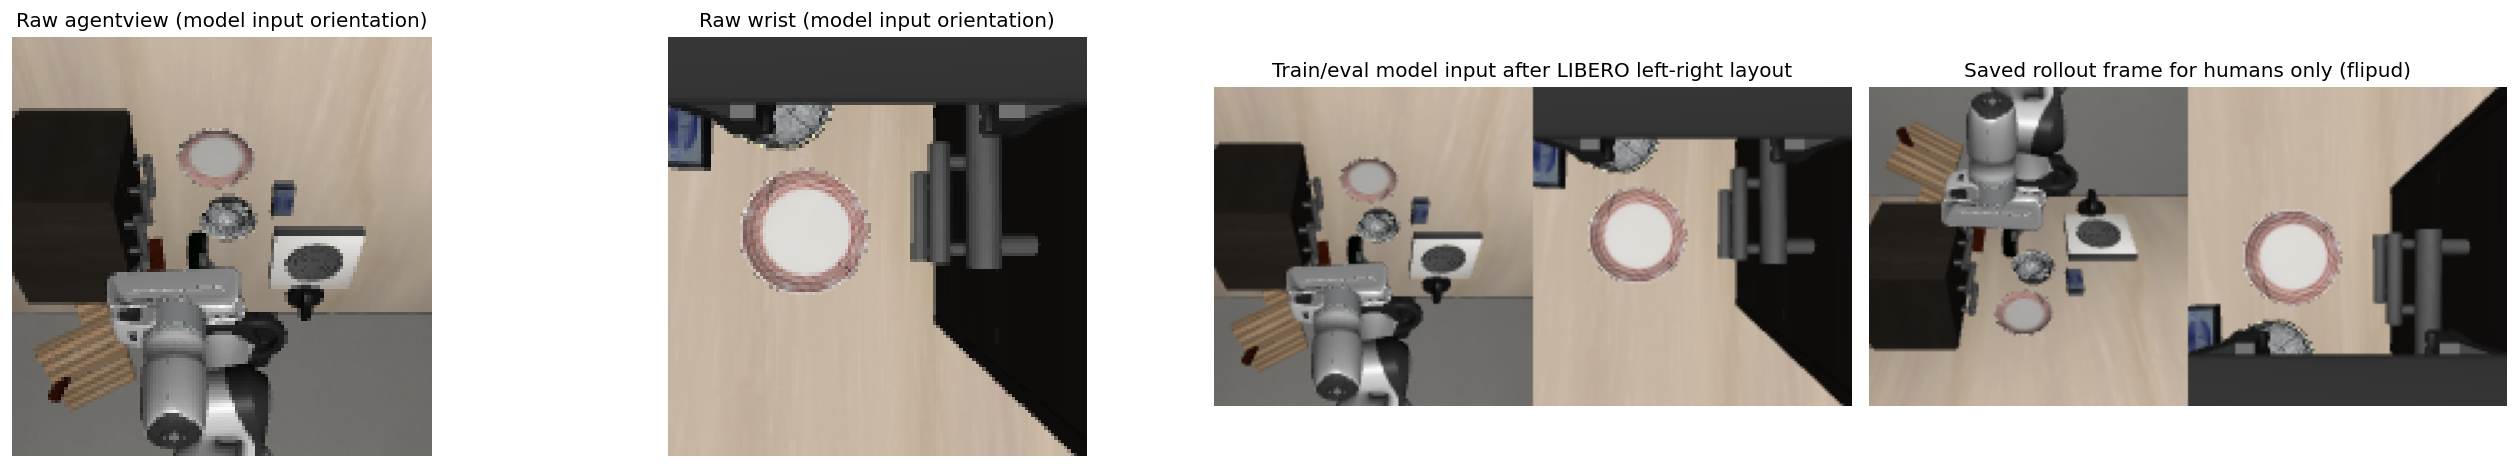

In [9]:
show_images(
    [
        agentview_rgb[frame_index],
        wrist_rgb[frame_index],
        train_frame,
        saved_rollout_frame,
    ],
    [
        "Raw agentview from LIBERO env/dataset",
        "Raw wrist from LIBERO env/dataset",
        "Train/eval model input after flip + LIBERO left-right layout",
        "Saved rollout frame from raw env obs",
    ],
    figsize=(22, 4),
)

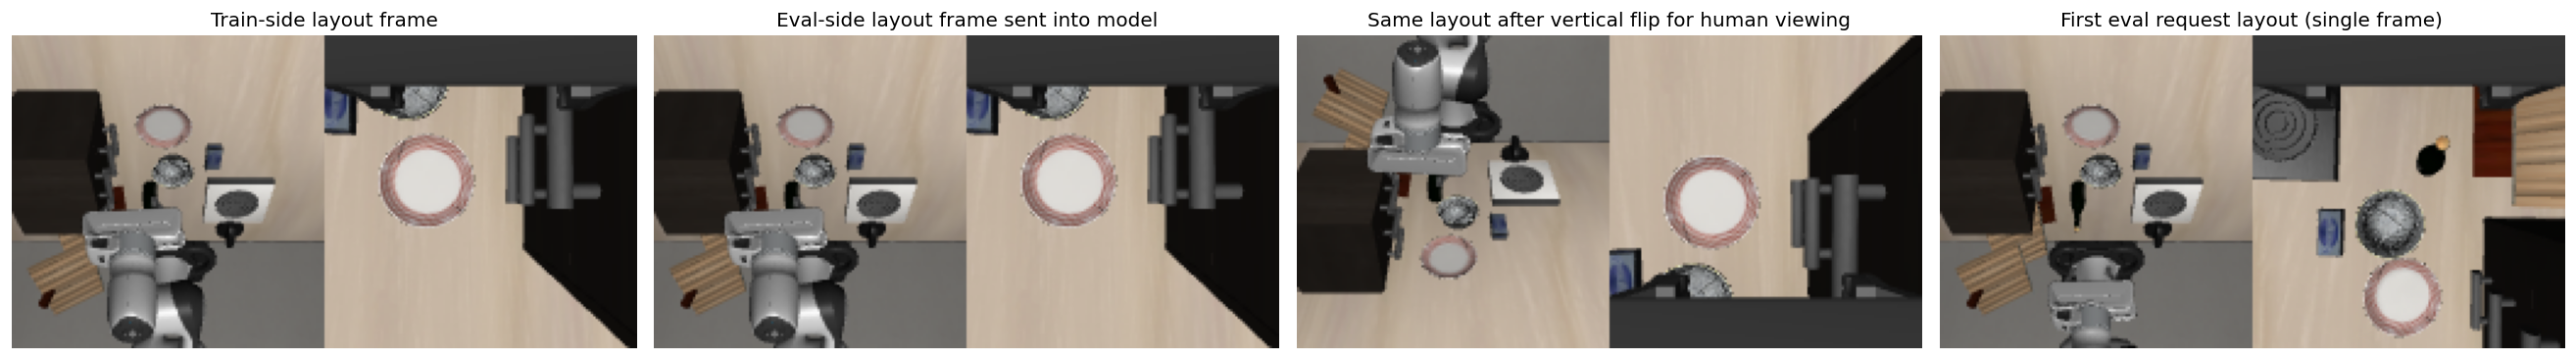

In [10]:
show_images(
    [
        train_frame,
        eval_frame,
        np.flipud(train_frame),
        first_request_frame,
    ],
    [
        "Train-side layout frame sent into model",
        "Eval-side layout frame sent into model",
        "Upright frame reconstructed directly from raw obs",
        "First eval request layout (single frame)",
    ],
    figsize=(22, 4),
)

## What to look for

- The training-side and eval-side model inputs are the same left-right layout for identical raw frames.
- The raw LIBERO observations are vertically inverted, but the shared `DreamTransform` now flips them before the policy sees them.
- Saved rollout visualization is still built from raw env observations, so it remains upright for humans.
- The prompt text now explicitly matches the new layout: left = static scene, right = wrist.